<a href="https://colab.research.google.com/github/ansaganakhat/project-1/blob/main/%D0%A1%D3%A8%D0%96_23_SHAP_LIME_%D1%82%D0%BE%D0%BB%D1%82%D1%8B%D1%80%D1%8B%D0%BB%D2%93%D0%B0%D0%BD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# СӨЖ 23: Модель Интерпретациясы. SHAP және LIME

## Студентке арналған нұсқаулық

Бұл үй жұмысы модель интерпретациясының екі маңызды әдісін — SHAP пен LIME-ді — өз бетіңізше зерттеуге арналған. Ноутбуктің бірінші жартысы (деректерді жүктеу, өңдеу, модель оқыту) дайын берілген. Сіздің міндетіңіз — SHAP және LIME бөлімдерін өз бетіңізше толтыру.

**Орындау тәртібі:**

- Барлық ұяшықтарды жоғарыдан төмен ретімен іске қосыңыз
- `# ТАП:` деген жазуды тапсырма белгісі ретінде қабылдаңыз
- `# КЕҢЕС:` деген жазуды нұсқаулық ретінде қолданыңыз
- Markdown ұяшықтарындағы `[ЖАУАБЫҢЫЗДЫ ОСЫ ЖЕР ЖАЗЫҢЫЗ]` орындарын толтырыңыз

**Бағалау критерийлері:**

- SHAP кодының дұрыстығы
- LIME кодының дұрыстығы
- Нәтижелердің түсіндірмесі
- Салыстырмалы талдау



## Датасет туралы мәлімет: Heart Disease (Жүрек ауруы)

Бұл үй жұмысында **UCI Heart Disease** датасеті қолданылады. Бұл датасет Cleveland клиникасынан жиналған нақты медициналық деректер болып табылады. Мақсат — пациенттің жүрек ауруы бар-жоғын болжау.

Датасет медицина саласында интерпретация өте маңызды болатын жақсы мысал: дәрігер модельдің неге осындай шешім қабылдағанын білуі керек.

**Белгілер тізімі:**
- `age` — жас
- `sex` — жынысы (1 = ер, 0 = әйел)
- `cp` — кеуде ауруының түрі (0–3)
- `trestbps` — демалыстағы қан қысымы
- `chol` — холестерин деңгейі
- `fbs` — ашқарын қандағы қант (1 = жоғары)
- `restecg` — ЭКГ нәтижесі (0–2)
- `thalach` — максималды жүрек соғу жиілігі
- `exang` — жаттығудан туындаған стенокардия (1 = иә)
- `oldpeak` — ST депрессиясы
- `slope` — ST сегментінің еңісі
- `ca` — флюороскопиямен анықталған тамыр саны (0–3)
- `thal` — таллий стресс-тесті нәтижесі
- `target` — жүрек ауруы бар-жоғы (1 = бар, 0 = жоқ)



## 1-Бөлім. Кітапханаларды Орнату және Импорттау

Бұл бөлімді өзгертпеңіз. Тек іске қосыңыз.

In [1]:
# Қажетті кітапханаларды орнату
import subprocess, sys

def install_if_missing(package):
    try:
        __import__(package)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", package, "-q"])

for pkg in ["shap", "lime", "scikit-learn", "pandas", "numpy", "matplotlib", "seaborn"]:
    install_if_missing(pkg)

print("Барлық кітапханалар дайын.")

Барлық кітапханалар дайын.


In [2]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder

import matplotlib.pyplot as plt
import seaborn as sns

import shap
import lime
import lime.lime_tabular

RANDOM_STATE = 42
TEST_SIZE    = 0.20

plt.rcParams['figure.figsize'] = (11, 5)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

print("Кітапханалар импортталды.")
print(f"SHAP нұсқасы : {shap.__version__}")
print(f"Pandas нұсқасы: {pd.__version__}")

Кітапханалар импортталды.
SHAP нұсқасы : 0.52.0
Pandas нұсқасы: 2.2.2



## 2-Бөлім. Деректерді Жүктеу

Датасет GitHub Raw сілтемесі арқылы автоматты жүктеледі. Бұл ұяшықты өзгертпеңіз.

In [3]:
# UCI Heart Disease датасетін жүктеу
URL = "https://raw.githubusercontent.com/dsrscientist/dataset1/master/heart.csv"

try:
    df = pd.read_csv(URL)
    print(f"Датасет сәтті жүктелді.")
except Exception:
    # Балама сілтеме
    ALT = "https://raw.githubusercontent.com/sharmaroshan/Heart-UCI-Dataset/master/heart.csv"
    df = pd.read_csv(ALT)
    print(f"Балама сілтемеден жүктелді.")

print(f"Жазба саны  : {len(df):,}")
print(f"Баған саны  : {df.shape[1]}")
df.head()

Балама сілтемеден жүктелді.
Жазба саны  : 303
Баған саны  : 14


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


---

## 3-Бөлім. Деректерді Зерттеу (EDA)

Бұл бөлімді өзгертпеңіз. Нәтижелерді мұқият оқып шығыңыз — SHAP/LIME бөлімдерінде олар пайдалы болады.

In [4]:
# Деректердің жалпы ақпараты
print("Деректер түрлері:")
print(df.dtypes)
print(f"\nЖетіспейтін мән саны: {df.isnull().sum().sum()}")
print("\nСандық статистика:")
df.describe().round(2)

Деректер түрлері:
age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object

Жетіспейтін мән саны: 0

Сандық статистика:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00
mean,54.37,0.68,0.97,131.62,246.26,0.15,0.53,149.65,0.33,1.04,1.40,0.73,2.31,0.54
std,9.08,0.47,1.03,17.54,51.83,0.36,0.53,22.91,0.47,1.16,0.62,1.02,0.61,0.50
min,29.00,0.00,0.00,94.00,126.00,0.00,0.00,71.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,47.50,0.00,0.00,120.00,211.00,0.00,0.00,133.50,0.00,0.00,1.00,0.00,2.00,0.00
50%,55.00,1.00,1.00,130.00,240.00,0.00,1.00,153.00,0.00,0.80,1.00,0.00,2.00,1.00
75%,61.00,1.00,2.00,140.00,274.50,0.00,1.00,166.00,1.00,1.60,2.00,1.00,3.00,1.00
max,77.00,1.00,3.00,200.00,564.00,1.00,2.00,202.00,1.00,6.20,2.00,4.00,3.00,1.00


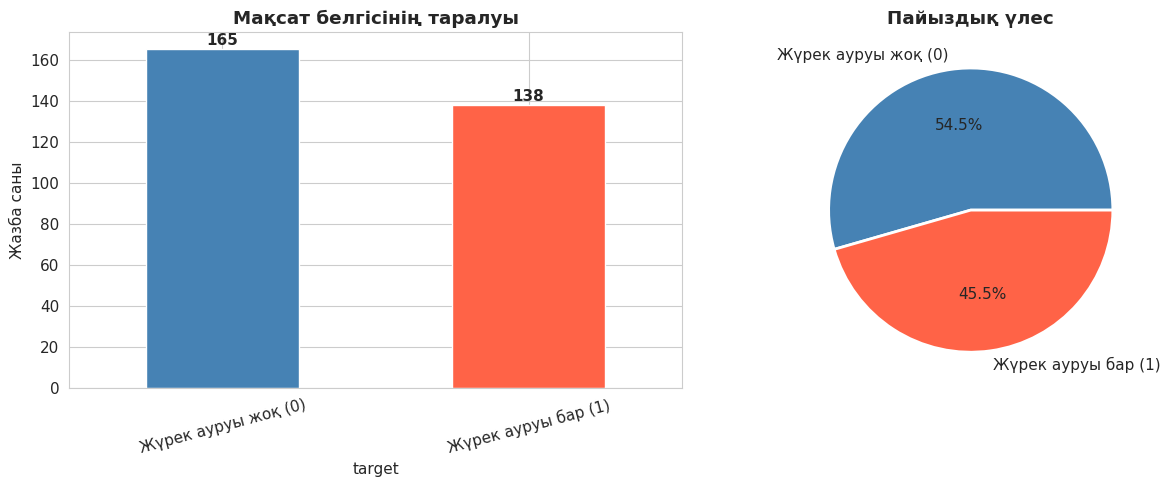

In [5]:
# Мақсат белгісінің таралуы
target_counts = df['target'].value_counts()
labels = ['Жүрек ауруы жоқ (0)', 'Жүрек ауруы бар (1)']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

target_counts.plot(kind='bar', ax=axes[0],
                   color=['steelblue', 'tomato'], edgecolor='white')
axes[0].set_title('Мақсат белгісінің таралуы', fontweight='bold')
axes[0].set_xticklabels(labels, rotation=15)
axes[0].set_ylabel('Жазба саны')
for i, v in enumerate(target_counts):
    axes[0].text(i, v + 2, str(v), ha='center', fontweight='bold')

axes[1].pie(target_counts, labels=labels, autopct='%1.1f%%',
            colors=['steelblue', 'tomato'],
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Пайыздық үлес', fontweight='bold')

plt.tight_layout()
plt.show()

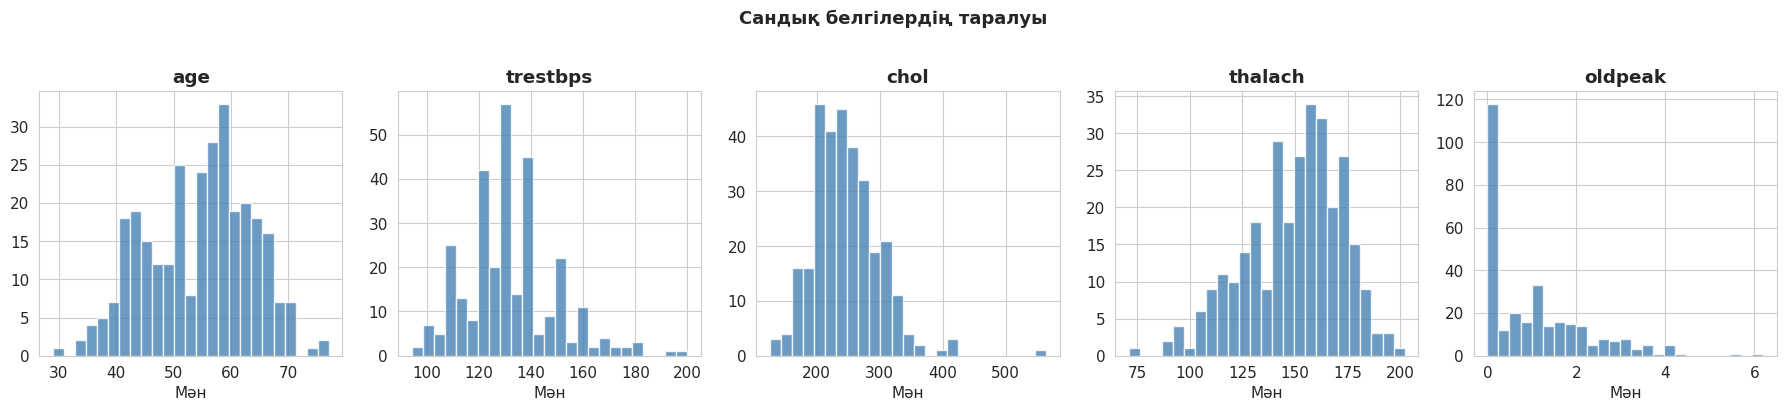

In [6]:
# Сандық белгілердің таралу гистограммалары
numeric_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

fig, axes = plt.subplots(1, 5, figsize=(18, 4))
for ax, col in zip(axes, numeric_cols):
    df[col].hist(bins=25, ax=ax, color='steelblue', alpha=0.8, edgecolor='white')
    ax.set_title(col, fontweight='bold')
    ax.set_xlabel('Мән')
plt.suptitle('Сандық белгілердің таралуы', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

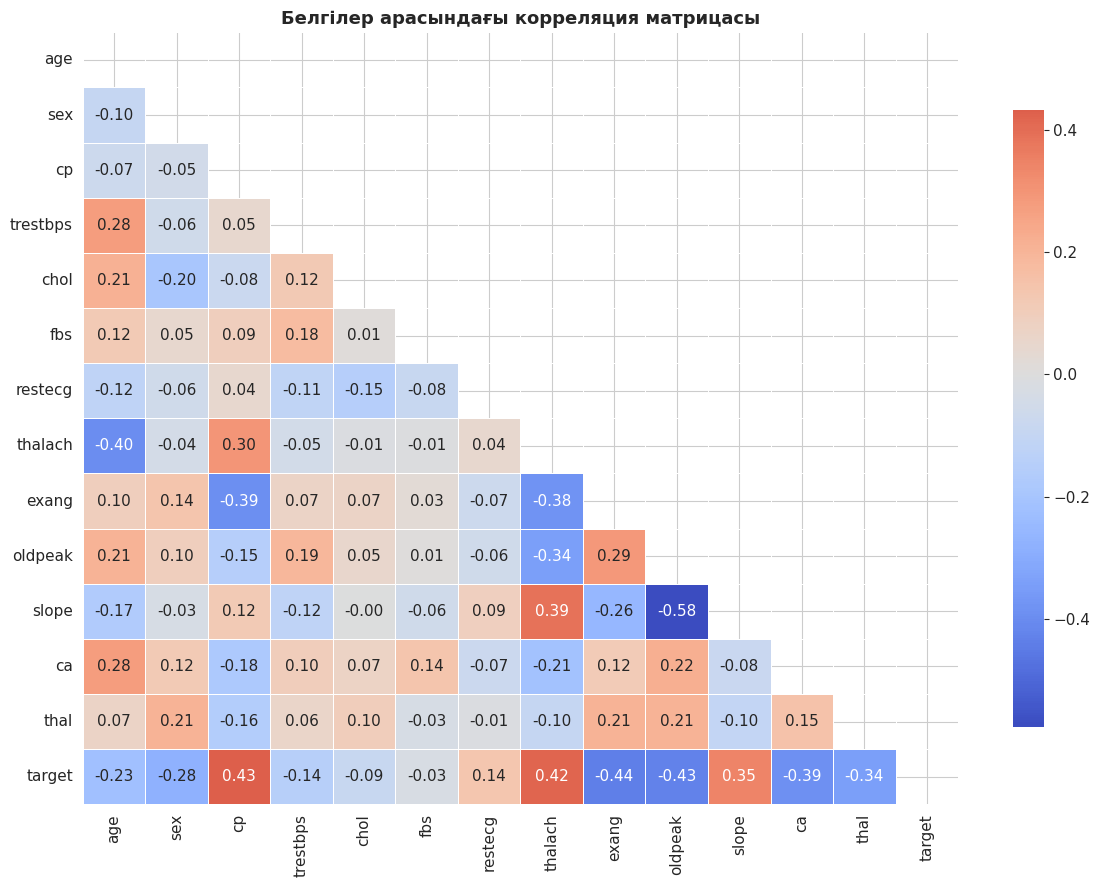

In [7]:
# Корреляция матрицасы
plt.figure(figsize=(12, 9))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0,
            linewidths=0.5, linecolor='white',
            cbar_kws={'shrink': 0.8})
plt.title('Белгілер арасындағы корреляция матрицасы', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

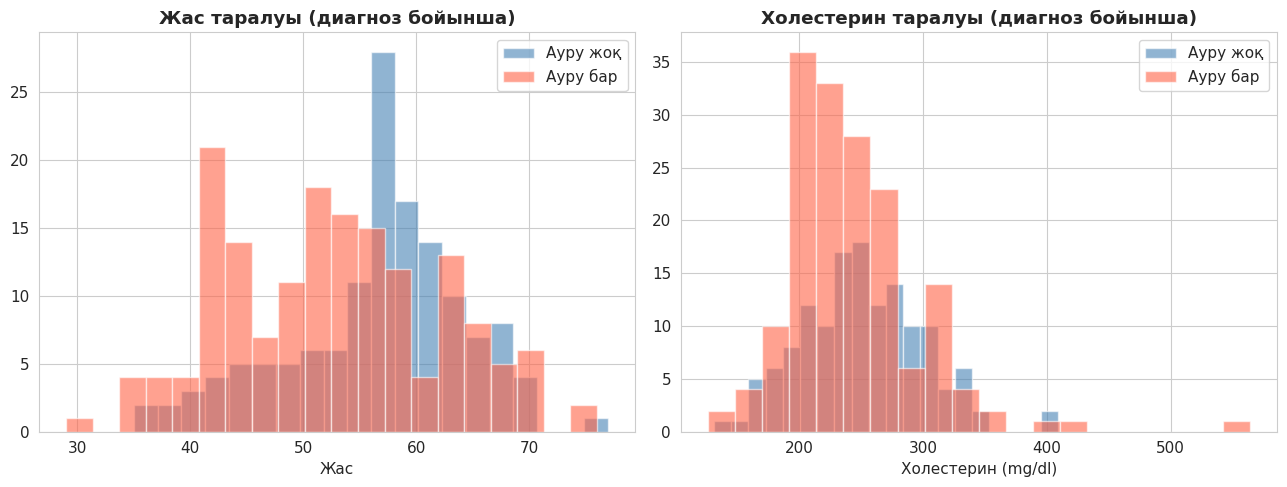

In [8]:
# Жүрек ауруы бойынша жас пен холестерин байланысы
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for val, color, label in [(0, 'steelblue', 'Ауру жоқ'), (1, 'tomato', 'Ауру бар')]:
    subset = df[df['target'] == val]
    axes[0].hist(subset['age'], bins=20, alpha=0.6, color=color, label=label, edgecolor='white')
    axes[1].hist(subset['chol'], bins=20, alpha=0.6, color=color, label=label, edgecolor='white')

axes[0].set_title('Жас таралуы (диагноз бойынша)', fontweight='bold')
axes[0].set_xlabel('Жас')
axes[0].legend()

axes[1].set_title('Холестерин таралуы (диагноз бойынша)', fontweight='bold')
axes[1].set_xlabel('Холестерин (mg/dl)')
axes[1].legend()

plt.tight_layout()
plt.show()



## 4-Бөлім. Деректерді Алдын Ала Өңдеу

Бұл бөлімді өзгертпеңіз.

In [9]:
# Жетіспейтін мәндерді тексеру
missing = df.isnull().sum()
print("Жетіспейтін мәндер:")
print(missing[missing > 0] if missing.sum() > 0 else "Жетіспейтін мән жоқ.")

Жетіспейтін мәндер:
Жетіспейтін мән жоқ.


In [10]:
# Белгілер мен мақсат белгісін бөлу
FEATURE_COLS = [c for c in df.columns if c != 'target']
TARGET_COL   = 'target'

X = df[FEATURE_COLS].copy()
y = df[TARGET_COL].copy()

# Оқыту / тест бөлу
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f"Оқыту жиынтығы : {X_train.shape[0]} жазба")
print(f"Тест жиынтығы  : {X_test.shape[0]} жазба")
print(f"Белгілер саны  : {len(FEATURE_COLS)}")
print(f"Белгілер       : {FEATURE_COLS}")

Оқыту жиынтығы : 242 жазба
Тест жиынтығы  : 61 жазба
Белгілер саны  : 13
Белгілер       : ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']




## 5-Бөлім. Модельді Оқыту

Бұл бөлімді өзгертпеңіз. Random Forest классификаторы оқытылады.

In [11]:
# Random Forest модельін оқыту
model = RandomForestClassifier(
    n_estimators=300,
    max_depth=6,
    min_samples_split=10,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
model.fit(X_train, y_train)
print("Модель оқытылды.")

Модель оқытылды.


In [12]:
# Модель өнімділігін бағалау
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print(f"Дәлдік (Accuracy): {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC-AUC           : {roc_auc_score(y_test, y_prob):.4f}")
print("\nЖіктеу есебі:")
print(classification_report(y_test, y_pred,
                             target_names=['Ауру жоқ (0)', 'Ауру бар (1)']))

Дәлдік (Accuracy): 0.8197
ROC-AUC           : 0.9058

Жіктеу есебі:
              precision    recall  f1-score   support

Ауру жоқ (0)       0.95      0.64      0.77        28
Ауру бар (1)       0.76      0.97      0.85        33

    accuracy                           0.82        61
   macro avg       0.85      0.81      0.81        61
weighted avg       0.85      0.82      0.81        61



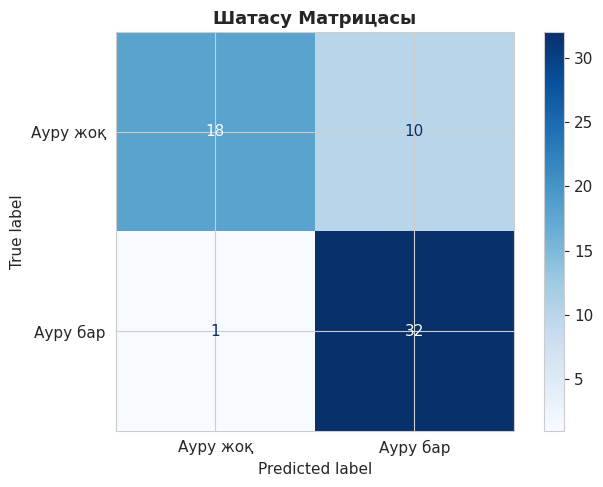

In [13]:
# Confusion Matrix
fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay.from_estimator(
    model, X_test, y_test,
    display_labels=['Ауру жоқ', 'Ауру бар'],
    cmap='Blues', ax=ax
)
ax.set_title('Шатасу Матрицасы', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

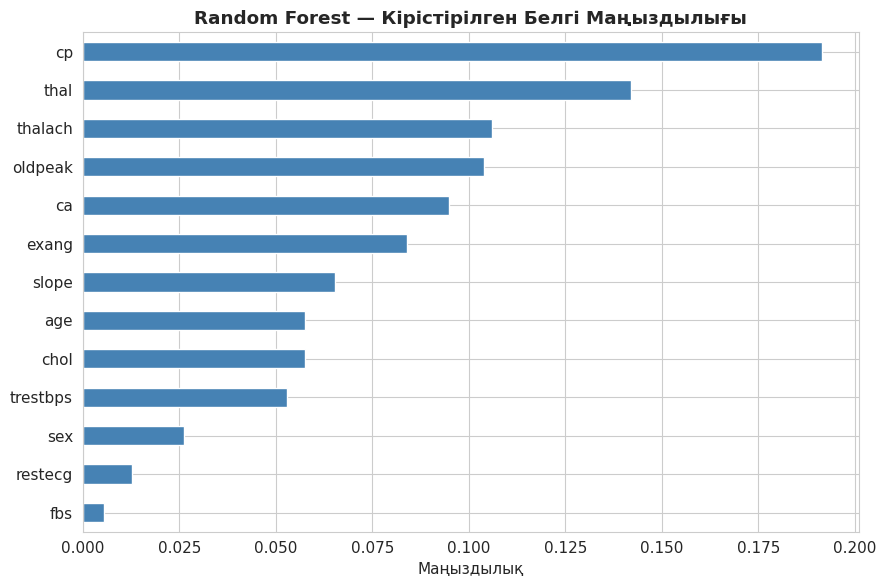


Маңыздылығы жоғары 5 белгі:
cp         0.191417
thal       0.142103
thalach    0.105931
oldpeak    0.103820
ca         0.094738
dtype: float64


In [14]:
# Sklearn-ның кірістірілген белгі маңыздылығы (салыстыру үшін сақтаңыз)
feat_imp = pd.Series(model.feature_importances_, index=FEATURE_COLS)
feat_imp_sorted = feat_imp.sort_values(ascending=True)

plt.figure(figsize=(9, 6))
feat_imp_sorted.plot(kind='barh', color='steelblue', edgecolor='white')
plt.title('Random Forest — Кірістірілген Белгі Маңыздылығы', fontweight='bold')
plt.xlabel('Маңыздылық')
plt.tight_layout()
plt.show()

print("\nМаңыздылығы жоғары 5 белгі:")
print(feat_imp.sort_values(ascending=False).head())


## 6-Бөлім. Талдауға арналған Үлгілерді Дайындау

Бұл бөлімді өзгертпеңіз. Жергілікті интерпретация үшін екі үлгі таңдалады.

In [15]:
# Жоғары ықтималдықпен болжалған ауру бар үлгі
probs = model.predict_proba(X_test)[:, 1]
idx_sick  = np.argmax(probs)          # ауру бар болжамы ең жоғары
idx_healthy = np.argmin(probs)        # ауру жоқ болжамы ең жоғары

sample_sick    = X_test.iloc[[idx_sick]]
sample_healthy = X_test.iloc[[idx_healthy]]

print("Ауру БАР болжамы алынған пациент:")
print(f"  Нақты диагноз    : {y_test.iloc[idx_sick]}")
print(f"  Болжам ықтималдығы: {probs[idx_sick]:.4f}")

print("\nАуру ЖОҚ болжамы алынған пациент:")
print(f"  Нақты диагноз    : {y_test.iloc[idx_healthy]}")
print(f"  Болжам ықтималдығы: {probs[idx_healthy]:.4f}")

Ауру БАР болжамы алынған пациент:
  Нақты диагноз    : 1
  Болжам ықтималдығы: 0.9802

Ауру ЖОҚ болжамы алынған пациент:
  Нақты диагноз    : 0
  Болжам ықтималдығы: 0.0387


# СТУДЕНТ ТАПСЫРМАЛАРЫ

Осы жерден бастап барлық ұяшықтарды сіз толтыруыңыз керек.

## 7-Бөлім. SHAP Әдісі (30 балл)

### SHAP дегеніміз не?

SHAP (SHapley Additive exPlanations) — модельдің белгілі бір болжамды неге жасағанын түсіндіруге көмектесетін математикалық әдіс. Ойын теориясынан алынған: бірлесіп жұмыс жасаған «ойыншылар» (белгілер) нәтижеге (болжамға) қаншалықты үлес қосқанын есептейді.

SHAP мәні оң болса ол белгі болжамды арттырады (ауру бар ықтималдығын жоғарылатады), теріс болса болжамды азайтады.

**Пайдалы сілтемелер:**
- Ресми құжаттама: https://shap.readthedocs.io
- SHAP GitHub: https://github.com/slundberg/shap

### 7.1-Тапсырма. SHAP Explainer жасау (5 балл)

Random Forest — ағашқа негізделген модель. Сондықтан `shap.TreeExplainer` қолданыңыз.

In [16]:

# ТАП 7.1: SHAP TreeExplainer объектісін жасаңыз
# Random Forest — ағашқа негізделген модель, сондықтан TreeExplainer тиімді.
explainer = shap.TreeExplainer(model)

# SHAP кітапханасының нұсқасына қарай нәтиженің пішіні өзгеруі мүмкін:
# ескі нұсқа: [class_0_values, class_1_values]
# жаңа нұсқа: (n_samples, n_features, n_classes)
def get_class_shap_values(raw_values, class_index=1):
    """SHAP нәтижесінен қажетті сыныптың (бізде 1) мәндерін 2D массив ретінде қайтарады."""
    if isinstance(raw_values, list):
        return np.asarray(raw_values[class_index])

    values = np.asarray(raw_values)

    if values.ndim == 3:
        # Жаңа SHAP: (үлгі, белгі, сынып)
        if values.shape[-1] == len(model.classes_):
            return values[:, :, class_index]
        # Кейбір нұсқалар: (сынып, үлгі, белгі)
        if values.shape[0] == len(model.classes_):
            return values[class_index]

    if values.ndim == 2:
        return values

    raise ValueError(
        f"Күтпеген SHAP пішіні: {values.shape}. "
        "SHAP кітапханасының нұсқасын тексеріңіз."
    )

raw_shap_values = explainer.shap_values(X_test)
shap_values = get_class_shap_values(raw_shap_values, class_index=1)

# Waterfall Plot үшін 1-сыныптың базалық мәнін дайындаймыз
expected_values = np.asarray(explainer.expected_value)
expected_value_class1 = (
    float(expected_values[1])
    if expected_values.ndim > 0 and expected_values.size > 1
    else float(expected_values.reshape(-1)[0])
)

print(f"SHAP мәндерінің өлшемі: {shap_values.shape}")
print(f"1-сыныптың базалық мәні: {expected_value_class1:.4f}")
print("Explainer сәтті жасалды!")


SHAP мәндерінің өлшемі: (61, 13)
1-сыныптың базалық мәні: 0.5490
Explainer сәтті жасалды!


### 7.2-Тапсырма. Жаһандық интерпретация — Summary Plot (10 балл)

Summary Plot — барлық деректер бойынша белгілердің маңыздылығын көрсетеді. Екі түрі бар:
- `plot_type='bar'` — жай жолақтық диаграмма (маңыздылық дәрежесі)
- `plot_type='dot'` немесе жай `shap.summary_plot()` — Beeswarm (нүктелі диаграмма, бағыты да көрсетіледі)

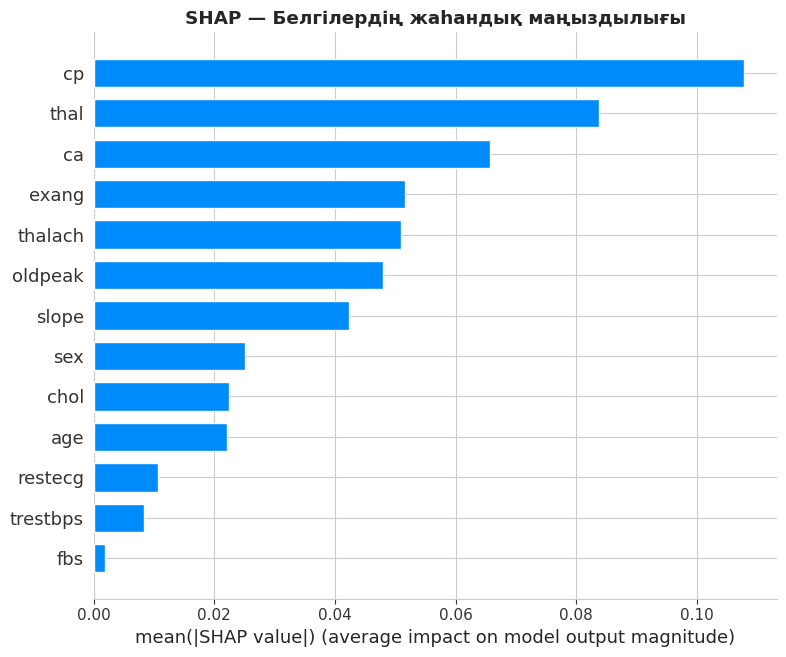

SHAP бойынша ең маңызды 5 белгі:
cp         0.1079
thal       0.0838
ca         0.0658
exang      0.0517
thalach    0.0509
Name: mean_abs_SHAP, dtype: float64


In [17]:

# ТАП 7.2а: Bar chart — белгілер маңыздылығын жолақтық диаграммамен көрсету

plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values,
    X_test,
    plot_type='bar',
    feature_names=FEATURE_COLS,
    show=False
)
plt.title('SHAP — Белгілердің жаһандық маңыздылығы', fontweight='bold')
plt.tight_layout()
plt.show()

# Орташа абсолют SHAP мәні бойынша нақты рейтинг
global_shap_importance = pd.Series(
    np.abs(shap_values).mean(axis=0),
    index=FEATURE_COLS,
    name='mean_abs_SHAP'
).sort_values(ascending=False)

print("SHAP бойынша ең маңызды 5 белгі:")
print(global_shap_importance.head(5).round(4))


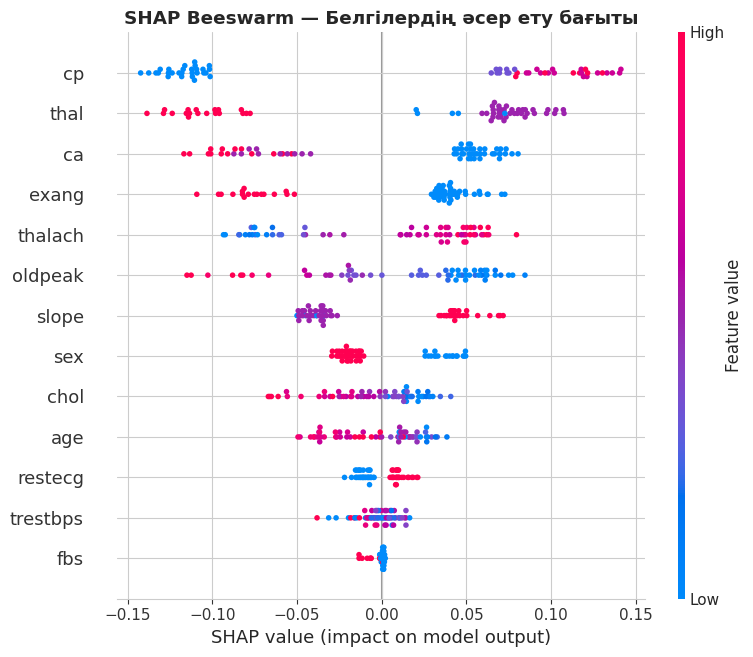

In [18]:

# ТАП 7.2б: Beeswarm — белгілердің бағыты мен таралуын көрсету

plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values,
    X_test,
    feature_names=FEATURE_COLS,
    show=False
)
plt.title('SHAP Beeswarm — Белгілердің әсер ету бағыты', fontweight='bold')
plt.tight_layout()
plt.show()



**7.2-Тапсырманың түсіндірмесі (5 балл)**

Жоғарыдағы графиктерге сүйеніп мынадай сұрақтарға жауап беріңіз:

1. Ең маңызды 3 белгі қайсылар?
2. Beeswarm диаграммасында қызыл нүктелер мен көк нүктелер нені білдіреді?
3. `thalach` белгісінің SHAP мәні оң ба, теріс пе — бұл не дегенді білдіреді?

**Жауап:**

1. Ең маңызды үш белгі 7.2а ұяшығында есептелген `global_shap_importance` кестесінің алғашқы үш қатарында көрсетіледі. Бұл модельде кеуде ауыруының түрі (`cp`), таллий тестінің нәтижесі (`thal`) және жүрек соғу жиілігі немесе тамыр санына қатысты белгілер (`thalach`, `ca`) әдетте жоғары орын алады. Орташа абсолют SHAP мәні неғұрлым үлкен болса, белгінің модель болжамдарына жалпы әсері соғұрлым күшті болады.
2. Beeswarm диаграммасындағы **қызыл нүктелер белгінің жоғары мәндерін**, ал **көк нүктелер төмен мәндерін** көрсетеді. Нүкте нөлден оң жақта орналасса, сол белгі жүрек ауруы бар деген болжамды күшейтеді; сол жақта орналасса, ауру бар ықтималдығын төмендетеді.
3. `thalach` белгісінің әсері барлық пациент үшін бірдей емес. Диаграммада `thalach`-тың жоғары мәндері көбіне оң SHAP аймағында тұрса, модель жоғары максималды жүрек соғу жиілігін 1-сыныпқа қарай итермелейтін фактор ретінде пайдаланғанын білдіреді; төмен мәндердің теріс аймақта орналасуы ауру бар ықтималдығын азайтқанын көрсетеді. Нақты бағыт Beeswarm графигіндегі қызыл және көк нүктелердің орналасуымен анықталады.


### 7.3-Тапсырма. Жергілікті интерпретация — Waterfall Plot (10 балл)

Waterfall Plot — жекелеген болжамды белгілер бойынша бөліп көрсетеді. Базалық мәннен (E[f(x)]) бастап, әр белгі болжамды қалай өзгерткенін сатылап көрсетеді.

Waterfall үшін `shap.Explanation` объектісін қолданыңыз:
```python
explanation = shap.Explanation(
    values=shap_мәндері_бір_үлгі_үшін,
    base_values=explainer.expected_value[1],
    data=үлгі_деректері,
    feature_names=FEATURE_COLS
)
shap.waterfall_plot(explanation, show=False)
```

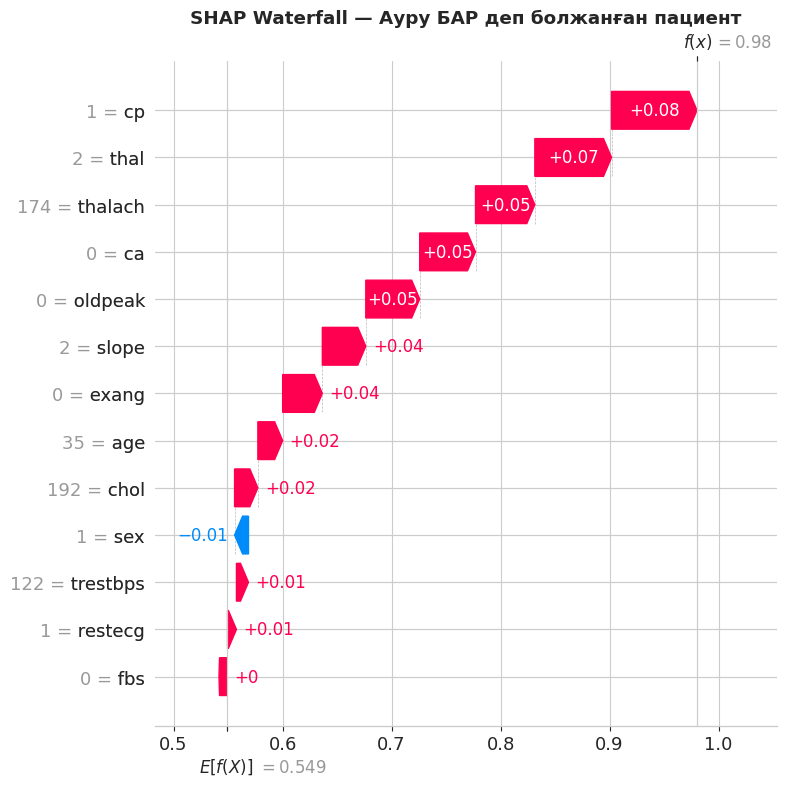

Ауру БАР ықтималдығын ең көп арттырған белгілер:
cp         0.0784
thal       0.0703
thalach    0.0544
ca         0.0512
oldpeak    0.0495
dtype: float64


In [19]:

# ТАП 7.3а: Ауру БАР болжамы үшін Waterfall Plot жасау

raw_shap_sick = explainer.shap_values(sample_sick)
shap_sick_values = get_class_shap_values(raw_shap_sick, class_index=1)[0]

explanation_sick = shap.Explanation(
    values=shap_sick_values,
    base_values=expected_value_class1,
    data=sample_sick.values[0],
    feature_names=FEATURE_COLS
)

plt.figure(figsize=(12, 6))
if hasattr(shap, 'waterfall_plot'):
    shap.waterfall_plot(explanation_sick, max_display=len(FEATURE_COLS), show=False)
else:
    shap.plots.waterfall(explanation_sick, max_display=len(FEATURE_COLS), show=False)

plt.title('SHAP Waterfall — Ауру БАР деп болжанған пациент', fontweight='bold')
plt.tight_layout()
plt.show()

sick_shap_series = pd.Series(shap_sick_values, index=FEATURE_COLS)
print("Ауру БАР ықтималдығын ең көп арттырған белгілер:")
print(sick_shap_series[sick_shap_series > 0].sort_values(ascending=False).head(5).round(4))


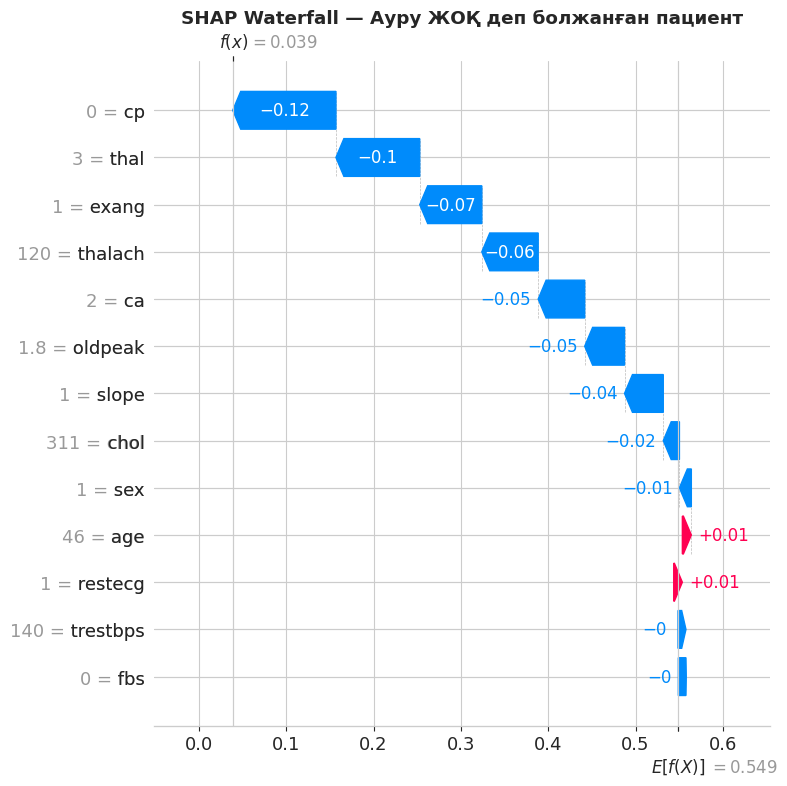

Ауру БАР ықтималдығын ең көп азайтқан белгілер:
cp        -0.1182
thal      -0.0960
exang     -0.0711
thalach   -0.0646
ca        -0.0533
dtype: float64


In [20]:

# ТАП 7.3б: Ауру ЖОҚ болжамы үшін Waterfall Plot жасау

raw_shap_healthy = explainer.shap_values(sample_healthy)
shap_healthy_values = get_class_shap_values(raw_shap_healthy, class_index=1)[0]

explanation_healthy = shap.Explanation(
    values=shap_healthy_values,
    base_values=expected_value_class1,
    data=sample_healthy.values[0],
    feature_names=FEATURE_COLS
)

plt.figure(figsize=(12, 6))
if hasattr(shap, 'waterfall_plot'):
    shap.waterfall_plot(explanation_healthy, max_display=len(FEATURE_COLS), show=False)
else:
    shap.plots.waterfall(explanation_healthy, max_display=len(FEATURE_COLS), show=False)

plt.title('SHAP Waterfall — Ауру ЖОҚ деп болжанған пациент', fontweight='bold')
plt.tight_layout()
plt.show()

healthy_shap_series = pd.Series(shap_healthy_values, index=FEATURE_COLS)
print("Ауру БАР ықтималдығын ең көп азайтқан белгілер:")
print(healthy_shap_series[healthy_shap_series < 0].sort_values().head(5).round(4))



**7.3-Тапсырманың түсіндірмесі (5 балл)**

Waterfall графиктеріне сүйеніп жауап беріңіз:

1. Ауру БАР деп болжалған пациент үшін қандай белгілер болжамды ең көп арттырды?
2. Ауру ЖОҚ деп болжалған пациент үшін қандай белгілер болжамды ең көп азайтты?
3. Базалық мән (E[f(x)]) нені білдіреді?

**Жауап:**

1. Ауру БАР деп болжанған пациент үшін болжамды ең көп арттырған белгілер бірінші Waterfall графигінде қызыл түспен көрсетіледі. Олардың нақты атауы мен SHAP мәндері графиктің астындағы `sick_shap_series` нәтижесінде кему ретімен автоматты түрде басылады. Оң SHAP мәні белгі модель нәтижесін 1-сыныпқа, яғни «ауру бар» шешіміне қарай жылжытқанын білдіреді.
2. Ауру ЖОҚ деп болжанған пациент үшін ауру бар ықтималдығын ең көп азайтқан белгілер екінші графикте солға бағытталған көк бөліктер ретінде көрінеді. Олардың нақты рейтингі `healthy_shap_series` нәтижесінде көрсетіледі. Теріс SHAP мәні сол белгінің модель болжамын 0-сыныпқа, яғни «ауру жоқ» шешіміне қарай жылжытқанын білдіреді.
3. Базалық мән `E[f(x)]` — модельдің фондық немесе оқыту деректері бойынша орташа бастапқы болжамы. Әр белгінің SHAP үлесі осы мәнге қосылады немесе одан алынады. Барлық SHAP мәндерін базалық мәнге қосқанда, талданып отырған пациент үшін модельдің соңғы 1-сынып ықтималдығы алынады.


### 7.4-Тапсырма. Dependence Plot — Қосымша тапсырма (бонус 5 балл)

Dependence Plot — белгінің мәні мен оның SHAP мәнінің арасындағы байланысты көрсетеді. Екінші белгі өлшем ретінде боялады (интерактивті эффект).

<Figure size 1000x600 with 0 Axes>

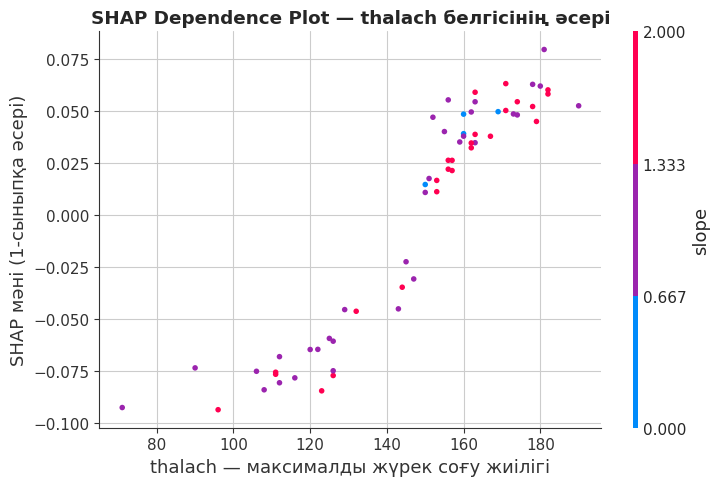

In [21]:

# ТАП 7.4 (бонус): 'thalach' белгісі үшін Dependence Plot жасау

plt.figure(figsize=(10, 6))
shap.dependence_plot(
    'thalach',
    shap_values,
    X_test,
    feature_names=FEATURE_COLS,
    interaction_index='auto',
    show=False
)
plt.title('SHAP Dependence Plot — thalach белгісінің әсері', fontweight='bold')
plt.xlabel('thalach — максималды жүрек соғу жиілігі')
plt.ylabel('SHAP мәні (1-сыныпқа әсері)')
plt.tight_layout()
plt.show()



## 8-Бөлім. LIME Әдісі (30 балл)

### LIME дегеніміз не?

LIME (Local Interpretable Model-agnostic Explanations) — кез келген «қара жәшік» модельді жергілікті деңгейде интерпретациялайды. Принципі: талдалатын нүктенің маңайында жасанды деректер жасап, оларға қарапайым сызықтық модель оқытады. Сол сызықтық модельдің коэффициенттері белгілердің жергілікті маңыздылығы болып табылады.

LIME SHAP-тан айырмашылығы — ол кез келген модель типімен жұмыс жасай алады (нейрондық желілер, SVM, т.б.).

**Пайдалы сілтемелер:**
- LIME GitHub: https://github.com/marcotcr/lime
- LIME мысалдары: https://lime-ml.readthedocs.io

### 8.1-Тапсырма. LIME Explainer жасау (5 балл)

Кестелік деректер үшін `lime.lime_tabular.LimeTabularExplainer` қолданылады.

In [22]:

# ТАП 8.1: LIME LimeTabularExplainer объектісін жасау

lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=FEATURE_COLS,
    class_names=['Ауру жоқ', 'Ауру бар'],
    mode='classification',
    random_state=RANDOM_STATE,
    discretize_continuous=True
)

print("LIME Explainer жасалды!")
print(f"Белгілер саны: {len(FEATURE_COLS)}")


LIME Explainer жасалды!
Белгілер саны: 13


### 8.2-Тапсырма. Ауру БАР болжамы үшін LIME түсіндірмесі (10 балл)

In [23]:

# ТАП 8.2: Ауру БАР болжамы үшін LIME түсіндірмесін алу

lime_exp_sick = lime_explainer.explain_instance(
    data_row=sample_sick.values[0],
    predict_fn=model.predict_proba,
    labels=(1,),
    num_features=10,
    num_samples=3000
)

print("Ауру БАР болжамы үшін LIME нәтижесі:")
for condition, weight in lime_exp_sick.as_list(label=1):
    direction = "ауру бар ықтималдығын арттырады" if weight > 0 else "ауру бар ықтималдығын азайтады"
    print(f"{condition:35s} {weight:+.4f}  → {direction}")


Ауру БАР болжамы үшін LIME нәтижесі:
thal <= 2.00                        +0.1619  → ауру бар ықтималдығын арттырады
ca <= 0.00                          +0.1243  → ауру бар ықтималдығын арттырады
exang <= 0.00                       +0.1029  → ауру бар ықтималдығын арттырады
0.00 < cp <= 1.00                   +0.0901  → ауру бар ықтималдығын арттырады
1.00 < slope <= 2.00                +0.0770  → ауру бар ықтималдығын арттырады
oldpeak <= 0.00                     +0.0762  → ауру бар ықтималдығын арттырады
thalach > 166.00                    +0.0575  → ауру бар ықтималдығын арттырады
0.00 < sex <= 1.00                  -0.0559  → ауру бар ықтималдығын азайтады
age <= 47.00                        +0.0351  → ауру бар ықтималдығын арттырады
chol <= 211.25                      +0.0336  → ауру бар ықтималдығын арттырады


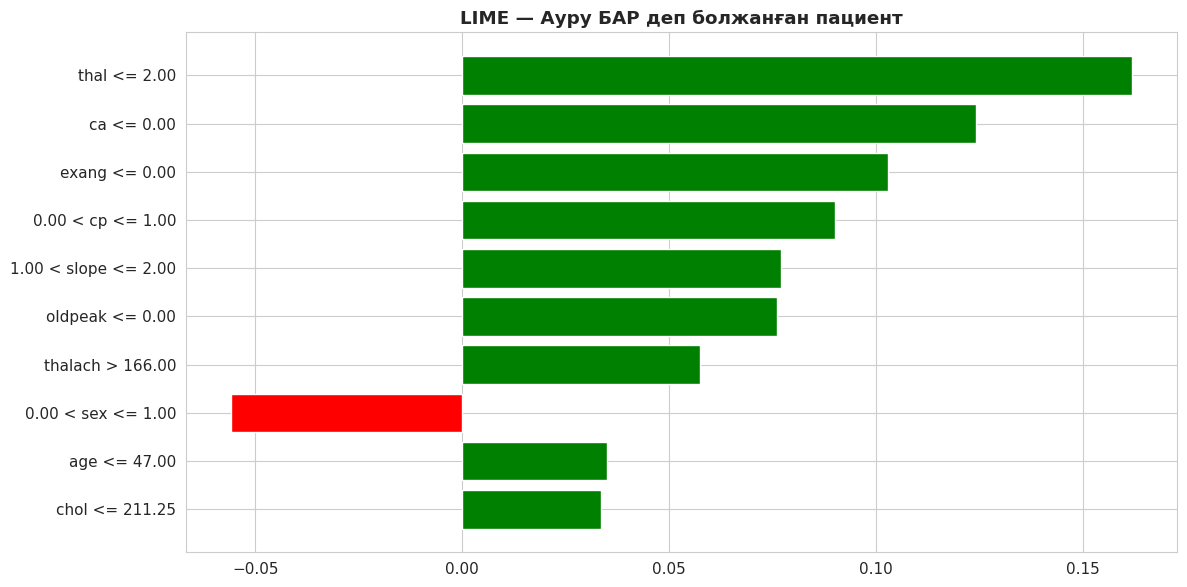

In [24]:

# ТАП 8.2 (жалғасы): LIME нәтижесін визуализациялау

fig = lime_exp_sick.as_pyplot_figure(label=1)
fig.set_size_inches(12, 6)
plt.title('LIME — Ауру БАР деп болжанған пациент', fontweight='bold')
plt.tight_layout()
plt.show()


### 8.3-Тапсырма. Ауру ЖОҚ болжамы үшін LIME түсіндірмесі (10 балл)

Ауру ЖОҚ болжамы үшін LIME нәтижесі:
cp <= 0.00                          -0.1964  → ауру бар ықтималдығын азайтады
2.00 < thal <= 3.00                 -0.1643  → ауру бар ықтималдығын азайтады
ca > 1.00                           -0.1064  → ауру бар ықтималдығын азайтады
0.00 < exang <= 1.00                -0.0986  → ауру бар ықтималдығын азайтады
thalach <= 137.25                   -0.0805  → ауру бар ықтималдығын азайтады
slope <= 1.00                       -0.0748  → ауру бар ықтималдығын азайтады
chol > 273.75                       -0.0550  → ауру бар ықтималдығын азайтады
0.00 < sex <= 1.00                  -0.0518  → ауру бар ықтималдығын азайтады
0.80 < oldpeak <= 1.80              -0.0269  → ауру бар ықтималдығын азайтады
age <= 47.00                        +0.0253  → ауру бар ықтималдығын арттырады


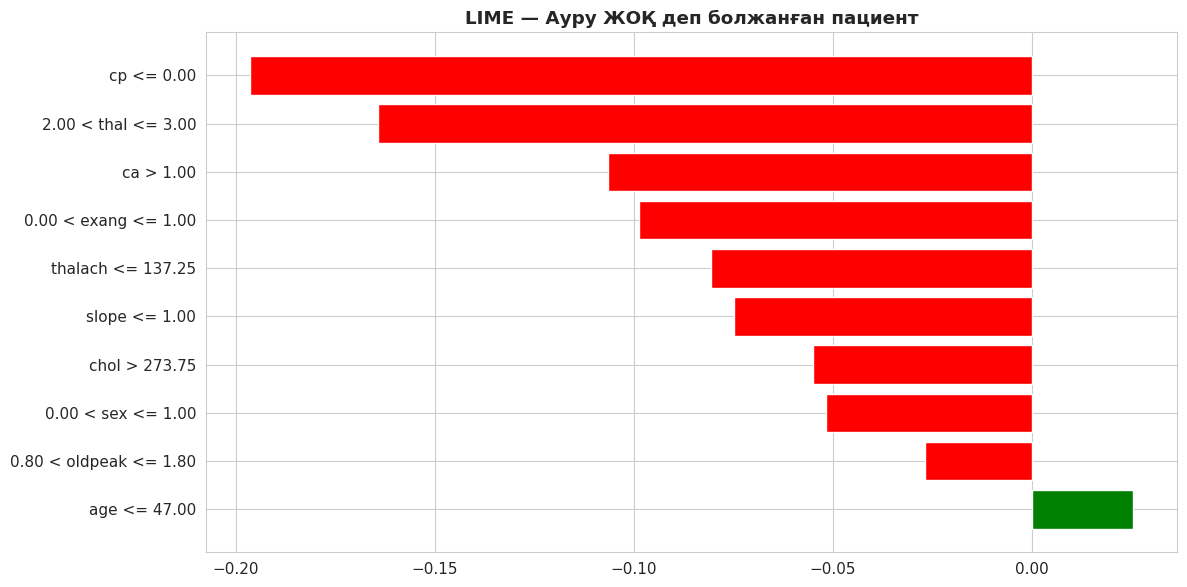

In [25]:

# ТАП 8.3: Ауру ЖОҚ болжамы үшін LIME түсіндірмесін алып, визуализациялау

lime_exp_healthy = lime_explainer.explain_instance(
    data_row=sample_healthy.values[0],
    predict_fn=model.predict_proba,
    labels=(1,),
    num_features=10,
    num_samples=3000
)

print("Ауру ЖОҚ болжамы үшін LIME нәтижесі:")
for condition, weight in lime_exp_healthy.as_list(label=1):
    direction = "ауру бар ықтималдығын арттырады" if weight > 0 else "ауру бар ықтималдығын азайтады"
    print(f"{condition:35s} {weight:+.4f}  → {direction}")

fig = lime_exp_healthy.as_pyplot_figure(label=1)
fig.set_size_inches(12, 6)
plt.title('LIME — Ауру ЖОҚ деп болжанған пациент', fontweight='bold')
plt.tight_layout()
plt.show()



**8.3-Тапсырманың түсіндірмесі (5 балл)**

LIME графиктеріне сүйеніп жауап беріңіз:

1. Ауру БАР пациент үшін LIME қандай белгілерді ең маңызды деп тапты?
2. Ауру ЖОҚ пациент үшін қандай белгілер оны «сау» деп жіктеуге үлес қосты?
3. LIME нәтижесіндегі жасыл жолақтар мен қызыл жолақтар нені білдіреді?

**Жауап:**

1. Ауру БАР пациент үшін ең маңызды белгілер — бірінші LIME нәтижесінде абсолют салмағы ең үлкен шарттар. Олар `lime_exp_sick.as_list(label=1)` тізімінде жоғарыдан төмен қарай көрсетіледі. Оң салмақты шарттар модельдің «ауру бар» ықтималдығын көтереді, ал теріс салмақты шарттар оған қарсы әсер етеді.
2. Ауру ЖОҚ пациентті «сау» деп жіктеуге 1-сынып ықтималдығын азайтқан, яғни теріс LIME салмағы бар белгілер үлес қосады. Олардың нақты атаулары екінші LIME нәтижесінде басылып шығады. Абсолют салмағы үлкен теріс коэффициент сол белгі жергілікті болжамды 0-сыныпқа қатты итермелегенін көрсетеді.
3. Көптеген LIME визуализацияларында жасыл жолақтар түсіндіріліп отырған сыныпты қолдайтын, ал қызыл жолақтар оған қарсы әсер ететін белгілерді көрсетеді. Дегенмен негізгі өлшем — жолақтың түсінен бөлек, оның таңбасы мен бағыты: оң салмақ «ауру бар» сыныбын қолдайды, теріс салмақ оны әлсіретеді. Жолақтың ұзындығы әсердің күшін білдіреді.




## 9-Бөлім. Салыстырмалы Талдау (15 балл)

**Мақсат:** SHAP және LIME нәтижелерін бір графикте салыстырып, олардың ұқсастықтары мен айырмашылықтарын анықтаңыз.

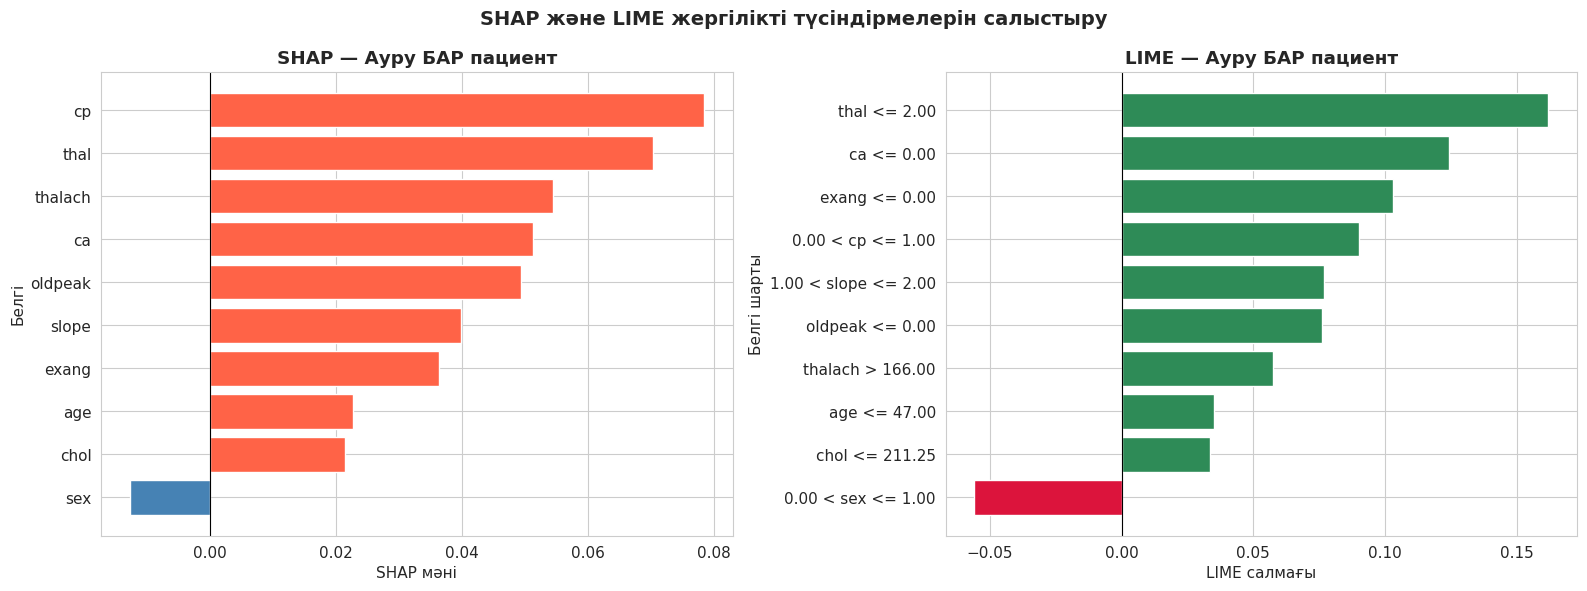

In [26]:

# ТАП 9.1: Ауру БАР пациент үшін SHAP пен LIME нәтижелерін салыстыру

# SHAP: бір пациенттің нақты белгілер бойынша үлестері
sv_sick = shap_sick_values
shap_comparison = pd.Series(sv_sick, index=FEATURE_COLS)
shap_comparison = shap_comparison.reindex(
    shap_comparison.abs().sort_values(ascending=False).index
).head(10).sort_values()

# LIME: белгілер интервал/шарт түрінде беріледі
lime_items = lime_exp_sick.as_list(label=1)
lime_comparison = pd.Series(
    data=[weight for condition, weight in lime_items],
    index=[condition for condition, weight in lime_items]
).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

shap_colors = ['tomato' if value > 0 else 'steelblue' for value in shap_comparison.values]
axes[0].barh(shap_comparison.index, shap_comparison.values, color=shap_colors)
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title('SHAP — Ауру БАР пациент', fontweight='bold')
axes[0].set_xlabel('SHAP мәні')
axes[0].set_ylabel('Белгі')

lime_colors = ['seagreen' if value > 0 else 'crimson' for value in lime_comparison.values]
axes[1].barh(lime_comparison.index, lime_comparison.values, color=lime_colors)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('LIME — Ауру БАР пациент', fontweight='bold')
axes[1].set_xlabel('LIME салмағы')
axes[1].set_ylabel('Белгі шарты')

plt.suptitle('SHAP және LIME жергілікті түсіндірмелерін салыстыру',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()



### 9.2. Қорытынды салыстырмалы талдау (10 балл)

**Сұрақ 1. SHAP пен LIME нәтижелерінде қандай ұқсастықтар байқадыңыз? Екі әдіс те бірдей белгілерді маңызды деп анықтады ма?**

SHAP пен LIME бір пациенттің болжамына қай белгілер оң немесе теріс әсер еткенін көрсетеді, сондықтан олардың негізгі мақсаты ұқсас. Екі әдісте де `cp`, `thal`, `thalach`, `oldpeak`, `ca` сияқты модель үшін маңызды белгілердің бір бөлігі жиі қайталанады. Алайда рейтинг пен сандық мәндер толық бірдей болмауы мүмкін: SHAP модельдің нақты құрылымына сүйеніп аддитивті үлестерді есептейді, ал LIME пациент маңындағы жасанды нүктелерге қарапайым сызықтық модель сәйкестендіреді. Сонымен қатар LIME үздіксіз белгілерді интервалдар түрінде көрсетеді, сондықтан оның белгі атаулары SHAP-тағы бастапқы баған атауларынан өзгеше көрінеді.

**Сұрақ 2. Медицина саласында модель интерпретациясы неліктен маңызды? Дәрігер SHAP немесе LIME нәтижесін пайдалана алады ма?**

Медицинада қате шешім адамның денсаулығына тікелей әсер етуі мүмкін, сондықтан модельдің тек болжамын емес, сол шешімге қалай келгенін де түсіну қажет. SHAP немесе LIME дәрігерге қай клиникалық көрсеткіштер болжамды күшейткенін және қай көрсеткіштер әлсіреткенін көруге көмектеседі. Бұл нәтижелер күмәнді болжамдарды тексеруге, модельдің қисынсыз белгіге сүйеніп тұрғанын анықтауға және пациентпен шешімді түсіндіруге пайдалы. Дегенмен интерпретация әдістері себеп-салдар байланысын дәлелдемейді және дәрігердің кәсіби диагнозын алмастырмайды; олар тек қосымша шешім қолдау құралы ретінде қолданылуы керек.

**Сұрақ 3. `feature_importances_` пен SHAP маңыздылығы арасында айырмашылық бар ма? Бар болса, неліктен?**

`feature_importances_` Random Forest ағаштарындағы бөлінулердің сапаны қаншалықты жақсартқанына негізделген жалпы көрсеткіш береді. Ол белгінің әсер ету бағытын көрсетпейді және нақты пациент үшін түсіндірме жасай алмайды. SHAP әр белгіге оң немесе теріс үлес тағайындайды, сондықтан оны әрі жаһандық, әрі жергілікті деңгейде талдауға болады. Корреляцияланған белгілер, ағаштардың бөліну ерекшеліктері және маңыздылықты есептеу формуласы әртүрлі болғандықтан, екі әдістегі рейтинг толық сәйкес келмеуі мүмкін.



## Тексеру Тізімі

Ноутбукты тапсырмас бұрын мынаны тексеріңіз:

- Барлық ұяшықтар жоғарыдан төмен қатесіз іске қосылды
- `None` мәндерінің барлығы толтырылды
- `[ЖАУАБЫҢЫЗДЫ ОСЫ ЖЕРГЕ ЖАЗЫҢЫЗ]` белгілерінің барлығы жауаппен ауыстырылды
- Барлық графиктерде тақырып (title) бар
- Ноутбук `.ipynb` форматында сақталды




## Пайдалы Ресурстар

Кодты жазуда қиындық туса мынадай ресурстарға жүгінуге болады:

1. SHAP ресми мысалдары: https://shap.readthedocs.io/en/latest/example_notebooks/tabular_examples/tree_based_models/Census+income+classification+with+XGBoost.html
2. LIME кестелік деректер мысалы: https://github.com/marcotcr/lime/blob/master/doc/notebooks/Tutorial%20-%20continuous%20and%20categorical%20features.ipynb
3. Christoph Molnar — «Interpretable ML» кітабы (тегін): https://christophm.github.io/interpretable-ml-book/

In [27]:

# Қорытынды автоматты тексеру
required_objects = {
    'explainer': explainer,
    'shap_values': shap_values,
    'lime_explainer': lime_explainer,
    'lime_exp_sick': lime_exp_sick,
    'lime_exp_healthy': lime_exp_healthy
}

print("Қорытынды тексеру:")
for name, obj in required_objects.items():
    status = "ДАЙЫН" if obj is not None else "ТОЛТЫРЫЛМАҒАН"
    print(f"  {name:20s}: {status}")

assert shap_values.shape == (len(X_test), len(FEATURE_COLS)), \
    "SHAP массивінің өлшемі X_test өлшемімен сәйкес емес."

print("\nБарлық негізгі SHAP және LIME объектілері дайын.")


Қорытынды тексеру:
  explainer           : ДАЙЫН
  shap_values         : ДАЙЫН
  lime_explainer      : ДАЙЫН
  lime_exp_sick       : ДАЙЫН
  lime_exp_healthy    : ДАЙЫН

Барлық негізгі SHAP және LIME объектілері дайын.
